In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
nav = pd.read_csv("../data/processed/cleaned_nav_history.csv")

transactions = pd.read_csv(
    "../data/processed/cleaned_investor_transactions.csv"
)

performance = pd.read_csv(
    "../data/processed/cleaned_scheme_performance.csv"
)

print("NAV:", nav.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)


NAV: (46000, 3)
Transactions: (32778, 13)
Performance: (40, 19)


In [24]:
import kaleido
print("kaleido installed successfully")

kaleido installed successfully


In [28]:
nav["date"] = pd.to_datetime(nav["date"])

sample_funds = nav["amfi_code"].unique()[:5]

filtered_nav = nav[
    nav["amfi_code"].isin(sample_funds)
]

fig = px.line(
    filtered_nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (Sample Funds)"
)


fig.show()

In [20]:
!pip install kaleido



   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   -------- ------------------------------- 1/5 [orjson]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   ---------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
fig.write_html(
    "../reports/charts/nav_trend.html"
)

print("NAV chart saved")

NAV chart saved


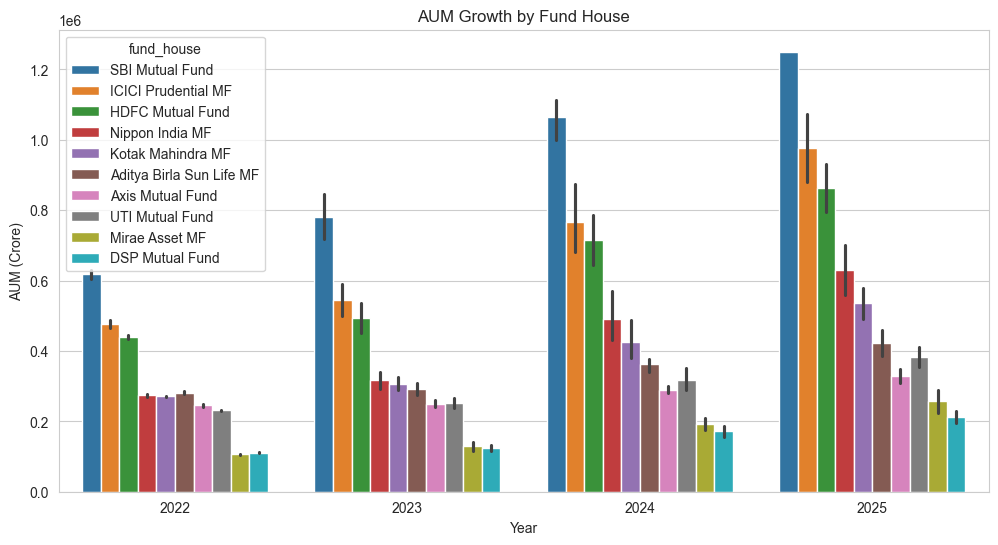

AUM chart completed


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.ylabel("AUM (Crore)")
plt.xlabel("Year")

plt.xticks(rotation=0)

plt.show()

print("AUM chart completed")

In [9]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.show()

print("SIP trend chart completed")

SIP trend chart completed


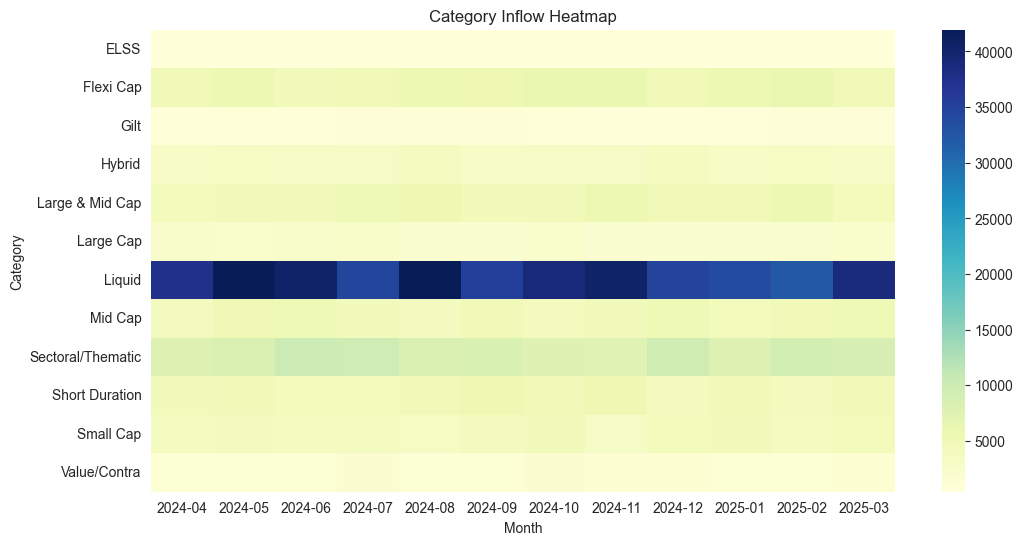

Category heatmap completed


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

category = pd.read_csv("../data/raw/05_category_inflows.csv")

pivot_table = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_table,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

print("Category heatmap completed")

In [11]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


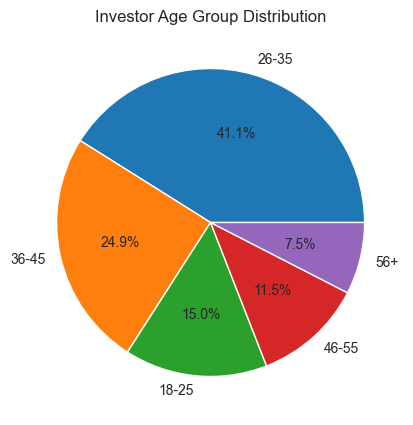

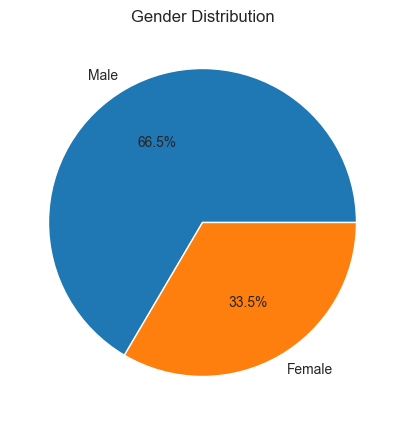

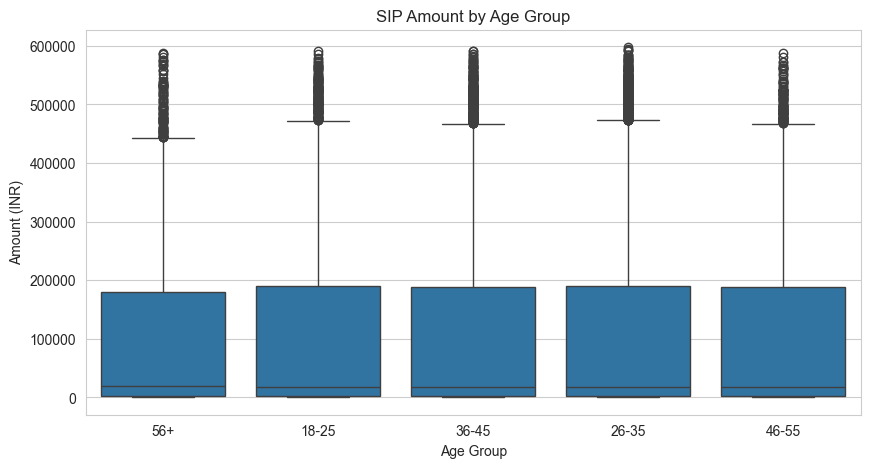

Investor demographics completed


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

# Convert amount to numeric
transactions["amount_inr"] = pd.to_numeric(transactions["amount_inr"])

# -------------------------
# Age Group Distribution
# -------------------------
plt.figure(figsize=(8,5))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

# -------------------------
# Gender Distribution
# -------------------------
plt.figure(figsize=(8,5))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

# -------------------------
# SIP Amount by Age Group
# -------------------------
plt.figure(figsize=(10,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

print("Investor demographics completed")

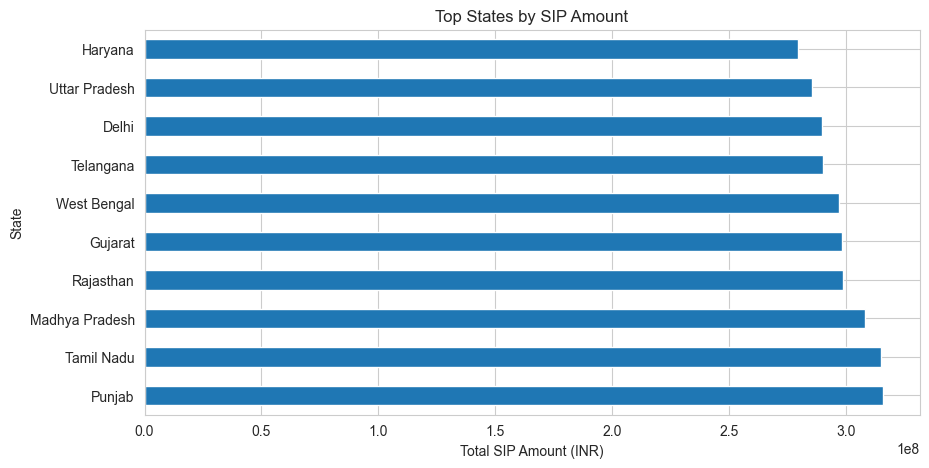

State-wise SIP chart completed


In [13]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

transactions["amount_inr"] = pd.to_numeric(transactions["amount_inr"])

state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

state_data.plot(kind="barh")

plt.title("Top States by SIP Amount")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.show()

print("State-wise SIP chart completed")

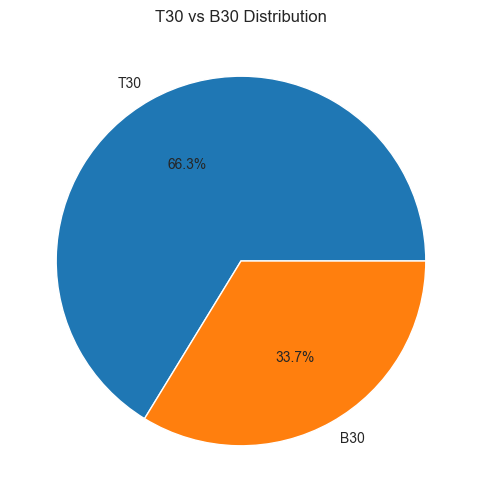

City tier chart completed


In [14]:
city_tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

city_tier.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.ylabel("")

plt.show()

print("City tier chart completed")

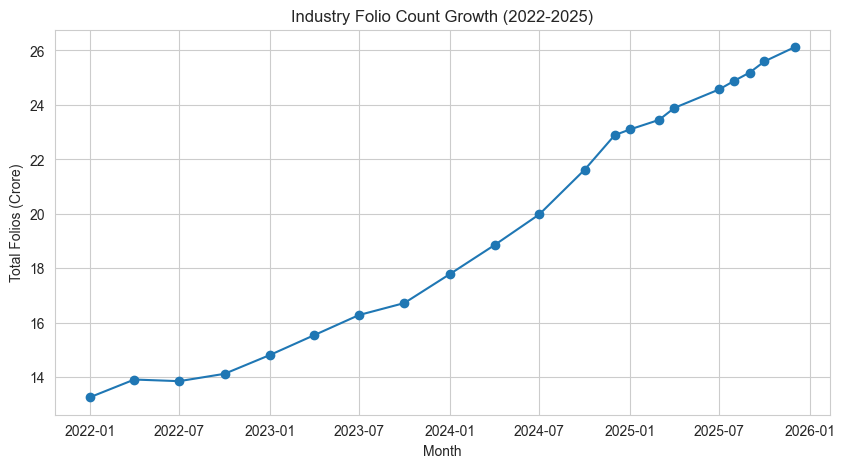

Folio growth chart completed


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(10,5))
plt.plot(folio["month"], folio["total_folios_crore"], marker="o")

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.show()

print("Folio growth chart completed")

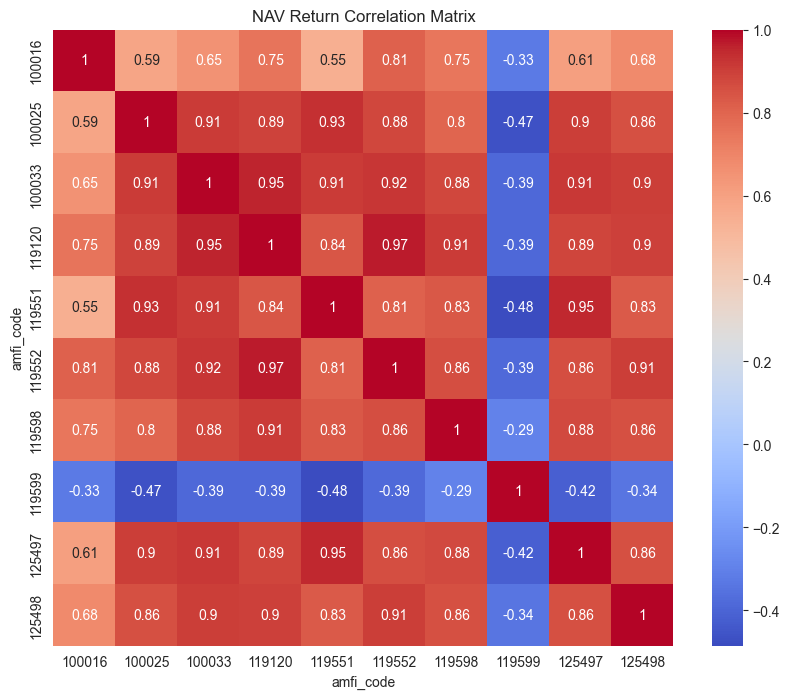

Correlation matrix completed


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Take first 10 schemes
top_schemes = nav["amfi_code"].unique()[:10]

nav10 = nav[nav["amfi_code"].isin(top_schemes)]

# Pivot table
pivot = nav10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Correlation matrix
corr = pivot.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("NAV Return Correlation Matrix")
plt.show()

print("Correlation matrix completed")

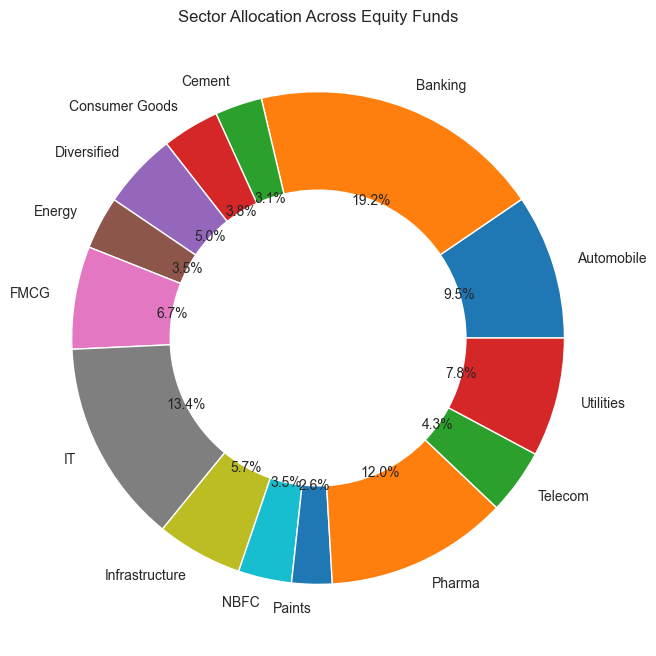

Sector allocation chart completed


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector_data = holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

print("Sector allocation chart completed")

In [ ]:
# Key EDA Findings

1. NAV values showed a strong upward trend between 2022 and 2025, reflecting overall mutual fund growth.

2. Most schemes experienced a significant rally during 2023, indicating bullish market sentiment.

3. SIP inflows increased consistently from around ₹11,500 Cr in 2022 to above ₹27,000 Cr by 2025.

4. December 2025 recorded the highest SIP inflow in the dataset.

5. SBI Mutual Fund maintained the highest Assets Under Management (AUM) across all years.

6. Liquid funds attracted the largest category-wise inflows among mutual fund categories.

7. Industry folio counts increased from approximately 13.26 Cr to 26.12 Cr, nearly doubling in four years.

8. T30 cities contributed around two-thirds of total mutual fund participation compared to B30 cities.

9. Equity-oriented sectors such as Banking, IT, Pharma, and Utilities dominated portfolio allocations.

10. NAV correlations among major schemes were generally positive, indicating similar market movement patterns.